Best Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9733333333333334

Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 1.         1.        ]

Average Accuracy:
0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.94      0.96        50
   virginica       0.94      0.98      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



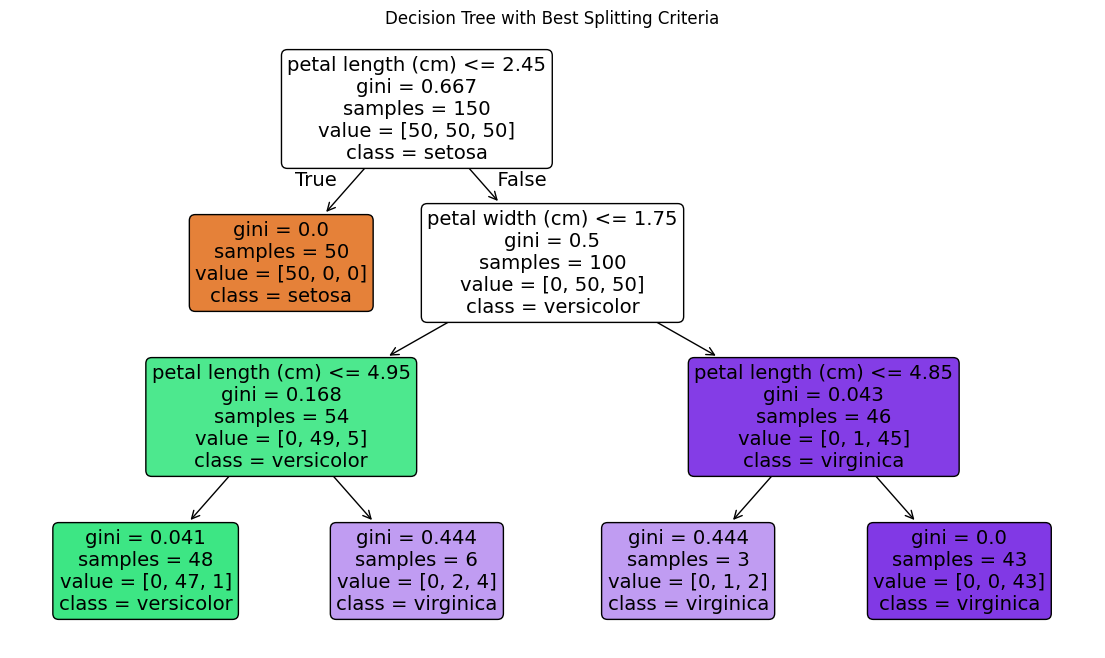

In [1]:
# Decision Tree with Best Splitting Criteria and Cross Validation

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Hyperparameter tuning for best splitting criteria
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3]
}

# Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X, y)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

# Best model
best_model = grid_search.best_estimator_

# Cross-validation scores of best model
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

# Train final model
best_model.fit(X, y)

# Predictions
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=iris.target_names))

# Visualize Decision Tree
plt.figure(figsize=(14, 8))
plot_tree(
    best_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree with Best Splitting Criteria")
plt.show()

In [2]:
# K-Nearest Neighbor Classifier Example
# Problem: Classify Iris flowers using K-NN

# Step 1: Import required libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load dataset
iris = load_iris()

# Convert dataset into DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

print("First 5 rows of dataset:")
print(df.head())

print("\nTarget names:")
print(iris.target_names)

# Step 3: Separate input features and output label
X = df.drop("target", axis=1)   # input features
y = df["target"]                # output class

# Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 5: Feature scaling
# K-NN is distance-based, so scaling is very important
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Create K-NN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Step 7: Train the model
knn.fit(X_train_scaled, y_train)

# Step 8: Make predictions
y_pred = knn.predict(X_test_scaled)

# Step 9: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Step 10: Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Scale the new input also
new_flower_scaled = scaler.transform(new_flower)

prediction = knn.predict(new_flower_scaled)

print("\nPredicted class:")
print(iris.target_names[prediction[0]])

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Target names:
['setosa' 'versicolor' 'virginica']

Accuracy:
1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro a

/home/chetanshreyan/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target flower_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Class names:
['setosa' 'versicolor' 'virginica']

Decision Tree
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy        

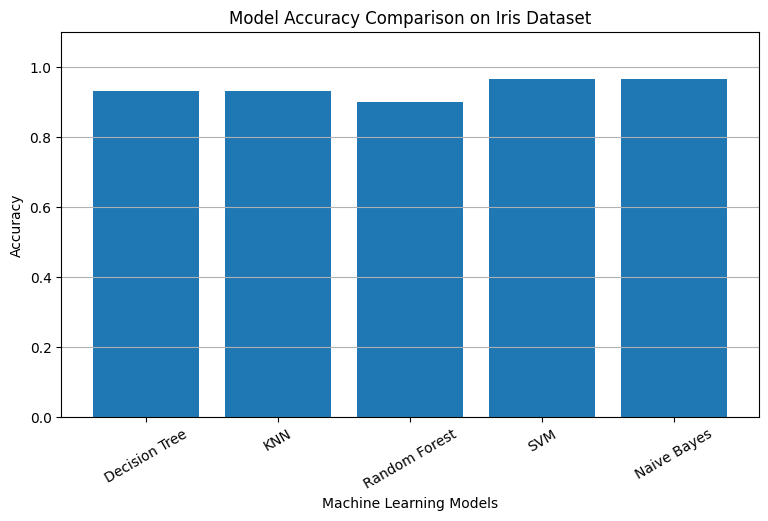

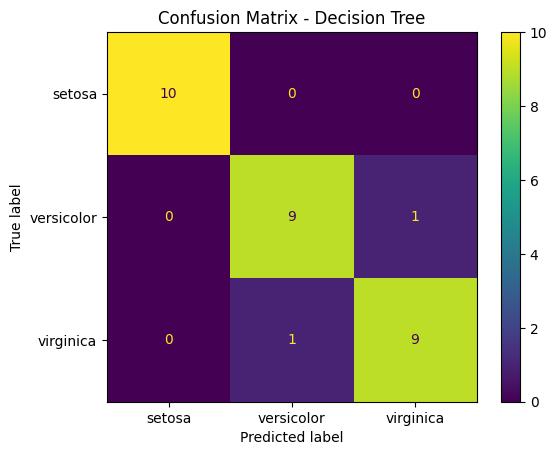

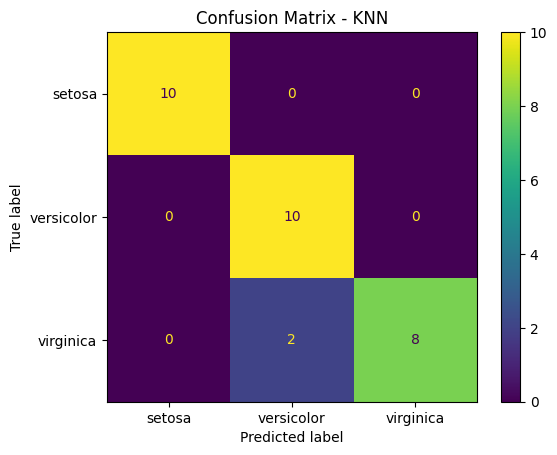

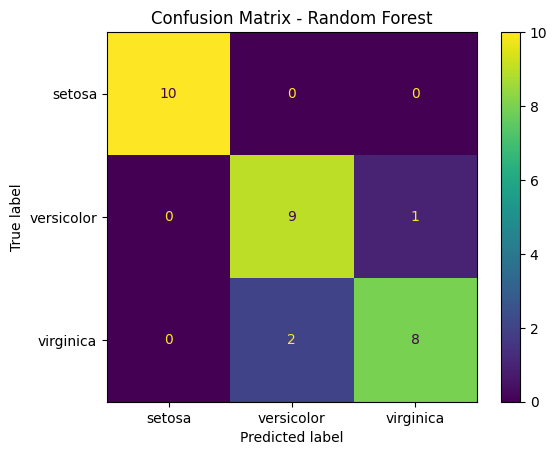

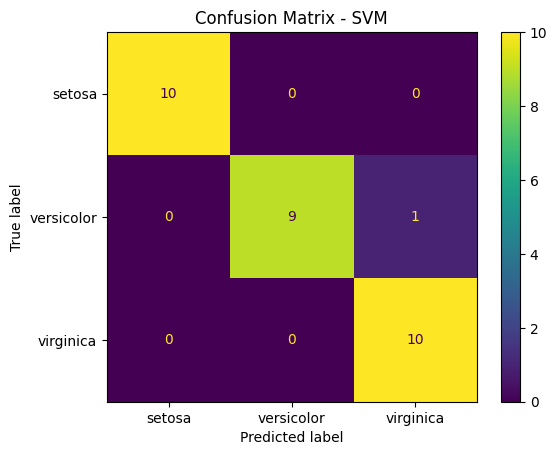

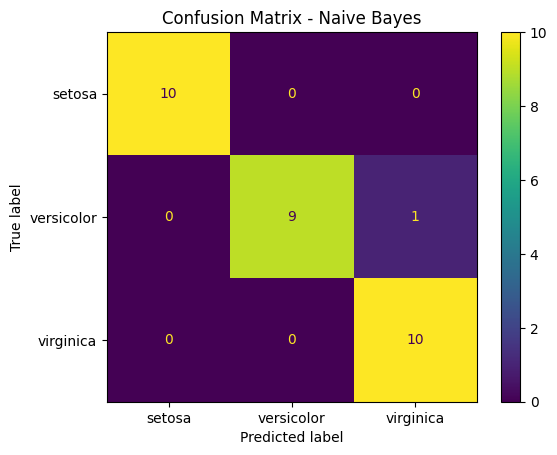

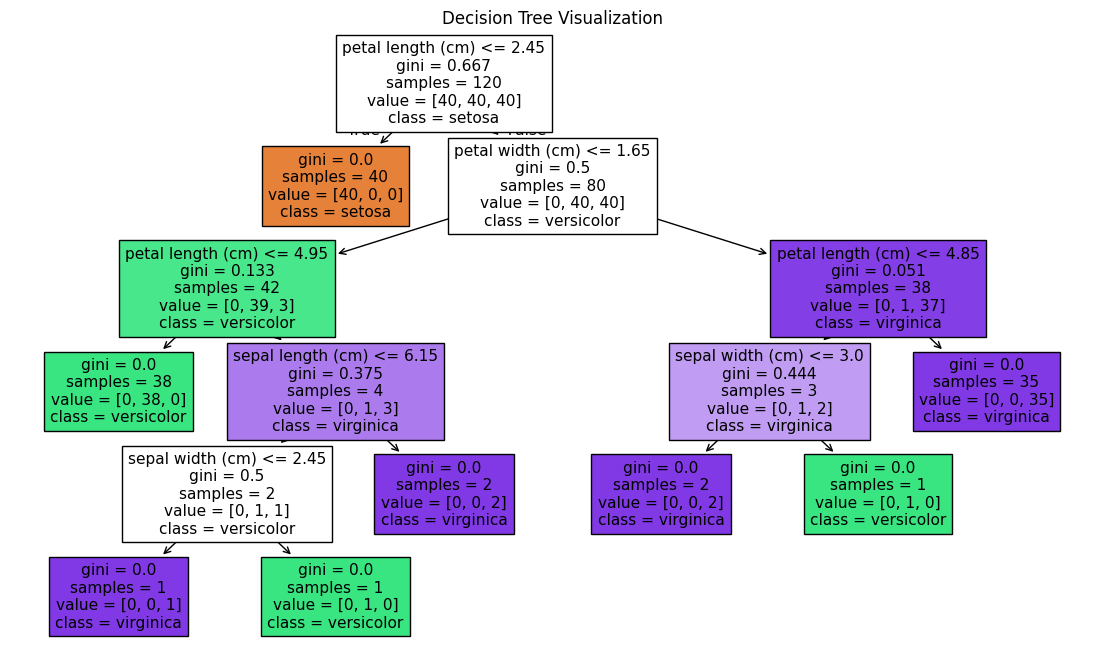


Prediction for New Sample:
Decision Tree => setosa
KNN => setosa
Random Forest => setosa
SVM => setosa
Naive Bayes => setosa


In [3]:
# ============================================
# ML Classification Models on Iris Dataset
# Decision Tree, KNN, Random Forest, SVM, Naive Bayes
# ============================================

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


# Step 2: Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["flower_name"] = df["target"].apply(lambda x: target_names[x])

print("First 5 rows of dataset:")
print(df.head())

print("\nClass names:")
print(target_names)


# Step 3: Split dataset
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Step 4: Feature scaling
# Scaling is very important for KNN and SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 5: Create models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Naive Bayes": GaussianNB()
}


# Step 6: Train and evaluate models
results = []

for model_name, model in models.items():

    # Use scaled data for KNN and SVM
    if model_name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })

    print("\n====================================")
    print(model_name)
    print("====================================")
    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


# Step 7: Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\nModel Accuracy Comparison:")
print(results_df)


# Step 8: Accuracy comparison visualization
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on Iris Dataset")
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()


# Step 9: Confusion matrix visualization for each model
for model_name, model in models.items():

    if model_name in ["KNN", "SVM"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


# Step 10: Decision tree visualization
dt_model = models["Decision Tree"]

plt.figure(figsize=(14, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


# Step 11: Predict a new flower sample
# Example input:
# sepal length = 5.1
# sepal width  = 3.5
# petal length = 1.4
# petal width  = 0.2

new_sample = [[5.1, 3.5, 1.4, 0.2]]

print("\nPrediction for New Sample:")
for model_name, model in models.items():

    if model_name in ["KNN", "SVM"]:
        new_sample_scaled = scaler.transform(new_sample)
        prediction = model.predict(new_sample_scaled)
    else:
        prediction = model.predict(new_sample)

    print(model_name, "=>", target_names[prediction[0]])